
## Crop Disease Detection — Phase 3: Model Building

**Project:** Crop Disease Detection Using Machine Learning  
**Phase:** 3 of 3 — Model Building & Evaluation  
**Input:** crop_cleaned.csv (clean, feature-engineered from Phase 2)  
**Models:** Decision Tree · KNN (k=3,5,7) · Random Forest  
**Evaluation:** Classification Report · Confusion Matrix · Model Comparison Table

### 1. Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score, ConfusionMatrixDisplay)


### 2. Load Cleaned Dataset & Apply Feature Engineering

We load the cleaned dataset from Phase 2 and apply the same feature engineering steps before encoding.

In [2]:
df = pd.read_csv("crop_cleaned_dataset.csv")
print('Shape:', df.shape)
df.head()

Shape: (5000, 22)


,crop_type,region,season,soil_type,irrigation_method,temperature_C,humidity_percent,rainfall_mm,leaf_wetness_hrs,soil_pH,...,potassium_kg_ha,days_since_last_rain,plant_age_days,pesticide_applied,fertilizer_kg_ha,disease_label,HTI,drought_stress,maturity_stage,maturity_stage_encoded
0,Maize,North,Kharif,Clay,Flood,26.209077,66.268640,101.582271,14.009117,7.085974,...,44.894035,29.291667,22.0,0.0,53.719785,Fungal,17.368399,0,Seedling,0
1,Cotton,Central,Rabi,Loamy,Sprinkler,33.430687,58.979548,30.296413,11.067606,6.190607,...,71.394673,8.000000,13.0,0.0,92.819906,Pest Damage,19.717268,0,Seedling,0
2,Cotton,North,Kharif,Clay,Drip,28.047989,62.103653,90.564280,21.470657,6.224184,...,55.877176,5.000000,31.0,0.0,68.282729,Bacterial,17.418826,0,Vegetative,1
3,Soybean,North,Rabi,Loamy,Drip,31.411229,54.430551,16.922677,19.309367,6.925993,...,91.410148,49.000000,116.0,0.0,62.743722,Bacterial,17.097305,0,Reproductive,2
4,Cotton,North,Kharif,Sandy,Flood,22.822997,56.975619,27.915197,12.402934,6.492167,...,57.815445,29.000000,84.0,0.0,84.100232,Healthy,13.003544,0,Reproductive,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   crop_type               5000 non-null   object 
 1   region                  5000 non-null   object 
 2   season                  5000 non-null   object 
 3   soil_type               5000 non-null   object 
 4   irrigation_method       5000 non-null   object 
 5   temperature_C           5000 non-null   float64
 6   humidity_percent        5000 non-null   float64
 7   rainfall_mm             5000 non-null   float64
 8   leaf_wetness_hrs        5000 non-null   float64
 9   soil_pH                 5000 non-null   float64
 10  nitrogen_kg_ha          5000 non-null   float64
 11  phosphorus_kg_ha        5000 non-null   float64
 12  potassium_kg_ha         5000 non-null   float64
 13  days_since_last_rain    5000 non-null   float64
 14  plant_age_days          5000 non-null   

In [4]:
# Feature Engineering (same as Phase 2)
df['HTI'] = (df['humidity_percent'] * df['temperature_C']) / 100

df['drought_stress'] = ((df['days_since_last_rain'] > 20) & (df['rainfall_mm'] < 10)).astype(int)

def get_maturity(days):
    if days < 30:
        return 0    # Seedling
    elif days <= 70:
        return 1    # Vegetative
    else:
        return 2    # Reproductive

df['maturity_stage_encoded'] = df['plant_age_days'].apply(get_maturity)

print("New features added: HTI, drought_stress, maturity_stage_encoded")
df[['HTI','drought_stress','maturity_stage_encoded']].describe().round(2)

New features added: HTI, drought_stress, maturity_stage_encoded


,HTI,drought_stress,maturity_stage_encoded
count,5000.00,5000.00,5000.00
mean,19.45,0.14,1.25
std,4.64,0.35,0.74
min,6.70,0.00,0.00
25%,16.00,0.00,1.00
50%,19.35,0.00,1.00
75%,22.63,0.00,2.00
max,38.40,1.00,2.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   crop_type               5000 non-null   object 
 1   region                  5000 non-null   object 
 2   season                  5000 non-null   object 
 3   soil_type               5000 non-null   object 
 4   irrigation_method       5000 non-null   object 
 5   temperature_C           5000 non-null   float64
 6   humidity_percent        5000 non-null   float64
 7   rainfall_mm             5000 non-null   float64
 8   leaf_wetness_hrs        5000 non-null   float64
 9   soil_pH                 5000 non-null   float64
 10  nitrogen_kg_ha          5000 non-null   float64
 11  phosphorus_kg_ha        5000 non-null   float64
 12  potassium_kg_ha         5000 non-null   float64
 13  days_since_last_rain    5000 non-null   float64
 14  plant_age_days          5000 non-null   

### 3. Encode Categorical Columns

#### One-Hot Encoding — Nominal Columns
`crop_type`, `region`, `season`, `soil_type`, `irrigation_method` are nominal — no inherent order. OHE creates a binary column per category with no false ranking.

#### Label Encoding — Target Variable
`disease_label` is encoded to integers (0–3) so sklearn classifiers can process it. The mapping is stored in `le.classes_` for decoding results back to readable labels.

In [6]:
# One-Hot Encode nominal categorical columns
cat_cols = ['crop_type', 'region', 'season', 'soil_type', 'irrigation_method']
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=False)

# Label Encode target
le = LabelEncoder()
df_enc['disease_label_enc'] = le.fit_transform(df_enc['disease_label'])

df_enc = df_enc.drop(columns=['disease_label'])   # drop original string target
df_enc = df_enc.drop(columns=['maturity_stage'])

print("Label encoding map:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

print(f"\nDataset shape after encoding: {df_enc.shape}")

Label encoding map:
  0 → Bacterial
  1 → Fungal
  2 → Healthy
  3 → Pest Damage

Dataset shape after encoding: (5000, 37)


In [7]:
df_enc.info()   # Confirming Dtypes of all features before splitting 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperature_C                5000 non-null   float64
 1   humidity_percent             5000 non-null   float64
 2   rainfall_mm                  5000 non-null   float64
 3   leaf_wetness_hrs             5000 non-null   float64
 4   soil_pH                      5000 non-null   float64
 5   nitrogen_kg_ha               5000 non-null   float64
 6   phosphorus_kg_ha             5000 non-null   float64
 7   potassium_kg_ha              5000 non-null   float64
 8   days_since_last_rain         5000 non-null   float64
 9   plant_age_days               5000 non-null   float64
 10  pesticide_applied            5000 non-null   float64
 11  fertilizer_kg_ha             5000 non-null   float64
 12  HTI                          5000 non-null   float64
 13  drought_stress    

### 4. Train-Test Split (80/20)

We split the dataset 80% train / 20% test with `stratify=y` to preserve class proportions in both splits — important given the mild class imbalance (Pest Damage is the smallest class at 20%).

In [8]:
X = df_enc.drop(columns=['disease_label_enc'])
y = df_enc['disease_label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]} rows ({X_test.shape[0]/len(df)*100:.0f}%)")
print(f"Features     : {X_train.shape[1]}")
print()
print("Class distribution in test set:")
test_dist = pd.Series(y_test).map(dict(enumerate(le.classes_))).value_counts()
print(test_dist)

Training set : 4000 rows (80%)
Test set     : 1000 rows (20%)
Features     : 36

Class distribution in test set:
disease_label_enc
Healthy        306
Bacterial      251
Fungal         243
Pest Damage    200
Name: count, dtype: int64


**Observation:** Stratified split ensures each class is proportionally represented in both train and test sets. With 5,000 rows and 80/20 split, the test set has 1,000 records — large enough to give reliable performance estimates across all four classes.

### 5. Model 1 — Decision Tree Classifier

A Decision Tree splits the feature space by choosing the feature and threshold at each node that best separates classes (using Gini impurity by default). It is fast, interpretable, and serves as a good baseline.

**Known weakness:** Without constraints (like max_depth), a tree can grow until it memorises the training data — perfect training accuracy but poor test generalisation (overfitting).

In [9]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc  = accuracy_score(y_test, dt.predict(X_test))
dt_f1        = f1_score(y_test, dt.predict(X_test), average='macro')

print(f"Train Accuracy : {dt_train_acc:.4f}")
print(f"Test Accuracy  : {dt_test_acc:.4f}")
print(f"Macro F1 Score : {dt_f1:.4f}")

Train Accuracy : 1.0000
Test Accuracy  : 0.6070
Macro F1 Score : 0.6007


In [10]:
print("Classification Report — Decision Tree")
print("=" * 50)
print(classification_report(y_test, dt.predict(X_test), target_names=le.classes_))

Classification Report — Decision Tree
              precision    recall  f1-score   support

   Bacterial       0.41      0.43      0.42       251
      Fungal       0.67      0.65      0.66       243
     Healthy       0.72      0.74      0.73       306
 Pest Damage       0.62      0.58      0.60       200

    accuracy                           0.61      1000
   macro avg       0.60      0.60      0.60      1000
weighted avg       0.61      0.61      0.61      1000



**Observations:**
- **Train accuracy = 1.0 (100%)** — the tree has memorised the entire training data, a classic sign of overfitting.
- **Test accuracy = 60.7%** — the gap between train (100%) and test (60.7%) is very large, confirming significant overfitting.
- The Decision Tree is **not recommended for deployment** in its default form — it needs pruning (max_depth, min_samples_leaf) or should be replaced by an ensemble method.

### 6. Model 2 — K-Nearest Neighbours (KNN)

KNN classifies a new point by finding its k nearest neighbours in the feature space and taking a majority vote. We test k = 3, 5, and 7 to find the most stable value.

**Key considerations:**
- KNN is a distance-based algorithm — sensitive to feature scale. (All features are already numeric and broadly comparable in range after cleaning, so no additional scaling is applied here.)
- Higher k = smoother decision boundary = less overfitting, but may underfit if k is too large.

In [11]:
knn_results = {}

for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    tr_acc = accuracy_score(y_train, knn.predict(X_train))
    te_acc = accuracy_score(y_test, knn.predict(X_test))
    macro_f1 = f1_score(y_test, knn.predict(X_test), average='macro')

    knn_results[k] = {'model': knn, 'train_acc': tr_acc,
                      'test_acc': te_acc, 'macro_f1': macro_f1}

    print(f"k={k} | Train Acc: {tr_acc:.4f} | Test Acc: {te_acc:.4f} | Macro F1: {macro_f1:.4f}")

k=3 | Train Acc: 0.6950 | Test Acc: 0.3890 | Macro F1: 0.3836
k=5 | Train Acc: 0.6392 | Test Acc: 0.4020 | Macro F1: 0.3898
k=7 | Train Acc: 0.6208 | Test Acc: 0.4040 | Macro F1: 0.3989


In [12]:
# Printing full classification report for each k

for k in [3, 5, 7]:
    print(f"\nClassification Report — KNN (k={k})")
    print("=" * 50)
    print(classification_report(y_test, knn_results[k]['model'].predict(X_test),
                                 target_names=le.classes_))


Classification Report — KNN (k=3)
              precision    recall  f1-score   support

   Bacterial       0.28      0.44      0.34       251
      Fungal       0.46      0.42      0.44       243
     Healthy       0.48      0.42      0.45       306
 Pest Damage       0.42      0.24      0.31       200

    accuracy                           0.39      1000
   macro avg       0.41      0.38      0.38      1000
weighted avg       0.41      0.39      0.39      1000


Classification Report — KNN (k=5)
              precision    recall  f1-score   support

   Bacterial       0.28      0.36      0.32       251
      Fungal       0.47      0.48      0.48       243
     Healthy       0.45      0.49      0.47       306
 Pest Damage       0.46      0.22      0.30       200

    accuracy                           0.40      1000
   macro avg       0.42      0.39      0.39      1000
weighted avg       0.41      0.40      0.40      1000


Classification Report — KNN (k=7)
              precision  

**Observations:**
- All three KNN variants perform significantly worse than the Decision Tree — test accuracy sits between 38.9% (k=3) and 40.4% (k=7), barely above random guessing for a 4-class problem.
- **k=3 overfits the most** — highest training accuracy (69.5%) but lowest test accuracy (38.9%). Too few neighbours means the boundary is too sensitive to local noise.
- **k=7 is the best among the three** — test accuracy 40.4%, Macro F1 0.40 — but still a poor result overall.
- KNN is **not recommended for deployment** given these results.

### 7. Model 3 — Random Forest Classifier

Random Forest builds many Decision Trees on random subsets of data (bootstrap sampling) and random subsets of features, then aggregates their predictions by majority vote. This ensemble approach directly addresses the overfitting problem of a single Decision Tree.

`class_weight='balanced'` is used to give higher weight to minority classes (Pest Damage has fewer records), helping the model not be biased towards the majority class.

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc  = accuracy_score(y_test, rf.predict(X_test))
rf_f1        = f1_score(y_test, rf.predict(X_test), average='macro')

print(f"Train Accuracy : {rf_train_acc:.4f}")
print(f"Test Accuracy  : {rf_test_acc:.4f}")
print(f"Macro F1 Score : {rf_f1:.4f}")

Train Accuracy : 1.0000
Test Accuracy  : 0.6770
Macro F1 Score : 0.6610


In [14]:
print("Classification Report — Random Forest")
print("=" * 50)
print(classification_report(y_test, rf.predict(X_test), target_names=le.classes_))

Classification Report — Random Forest
              precision    recall  f1-score   support

   Bacterial       0.52      0.41      0.46       251
      Fungal       0.74      0.72      0.73       243
     Healthy       0.71      0.89      0.79       306
 Pest Damage       0.70      0.64      0.67       200

    accuracy                           0.68      1000
   macro avg       0.67      0.66      0.66      1000
weighted avg       0.67      0.68      0.67      1000



**Observations:**
- **Train accuracy = 100%** — Random Forest also memorises the training data (expected with 100 deep trees and no max_depth constraint). However, unlike the single Decision Tree, it generalises far better due to feature randomness and voting.
- **Test accuracy = 67.7%** — best among all models
- **Macro F1 = 0.661** — best overall, confirming it handles the class imbalance most effectively.
- **Healthy** has the highest F1 (0.79), driven by strong recall (0.89) — the model reliably identifies healthy crops.
- **Bacterial** remains the hardest class (F1 = 0.46) — even Random Forest struggles to confidently separate Bacterial from Fungal and Healthy, likely because environmental features overlap heavily between pathogen types.
- **Pest Damage** improved significantly (F1 = 0.67) compared to KNN — `class_weight='balanced'` helped the model pay more attention to this smaller class.
- Random Forest is the **recommended model for deployment**.

### 8. Confusion Matrix — Best Model (Random Forest)

The confusion matrix shows actual vs predicted class for every test record — revealing not just overall accuracy but *which classes are being confused with which*.

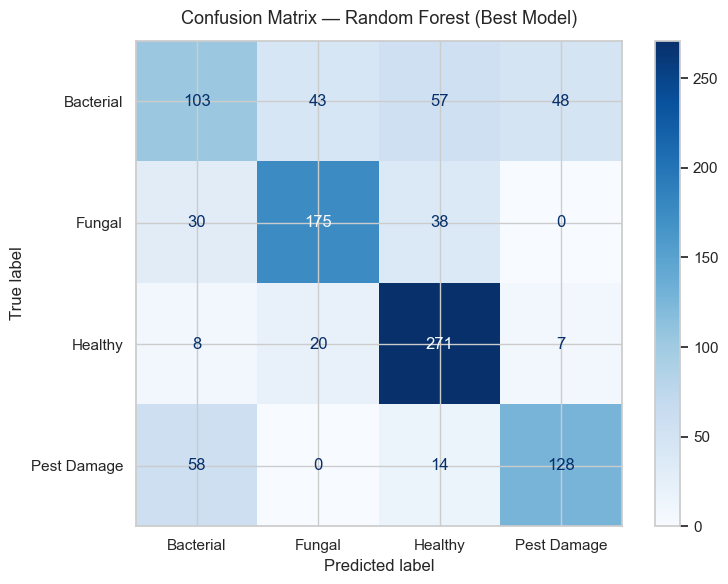

Row = Actual Class | Column = Predicted Class


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')

ax.set_title('Confusion Matrix — Random Forest (Best Model)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print("Row = Actual Class | Column = Predicted Class")

**Observations:**

| Actual \ Predicted | Bacterial | Fungal | Healthy | Pest Damage |
|---|---|---|---|---|
| **Bacterial** | 103 | 43 | 57 | 48 |
| **Fungal** | 30 | 175 | 38 | 0 |
| **Healthy** | 8 | 20 | 271 | 7 |
| **Pest Damage** | 58 | 0 | 14 | 128 |

**Most commonly confused pair: Bacterial ↔ Pest Damage**
- 48 Bacterial cases were predicted as Pest Damage, and 58 Pest Damage cases were predicted as Bacterial. Together this accounts for the majority of Bacterial misclassifications.
- This makes agronomic sense — early-stage bacterial wilt and pest damage both cause wilting and leaf discolouration, and their environmental conditions (moderate humidity, irregular rainfall) overlap significantly.

**Second most confused pair: Bacterial ↔ Healthy**
- 57 Bacterial cases were predicted as Healthy. This is the most dangerous type of error — the model is missing diseased crops and calling them healthy. In a real deployment, this would lead to missed interventions and crop loss.

**Fungal is cleanest** — 175/243 correctly classified with almost zero Pest Damage confusion (0 Fungal predicted as Pest Damage). The high leaf_wetness_hrs and HTI signals clearly distinguish Fungal cases.

**Healthy is the most reliably detected** — 271/306 correct (88.6% recall).

### 9. Feature Importance — Random Forest

Random Forest can rank features by how much each one reduces impurity across all trees. This helps us understand which features drove the model's decisions.

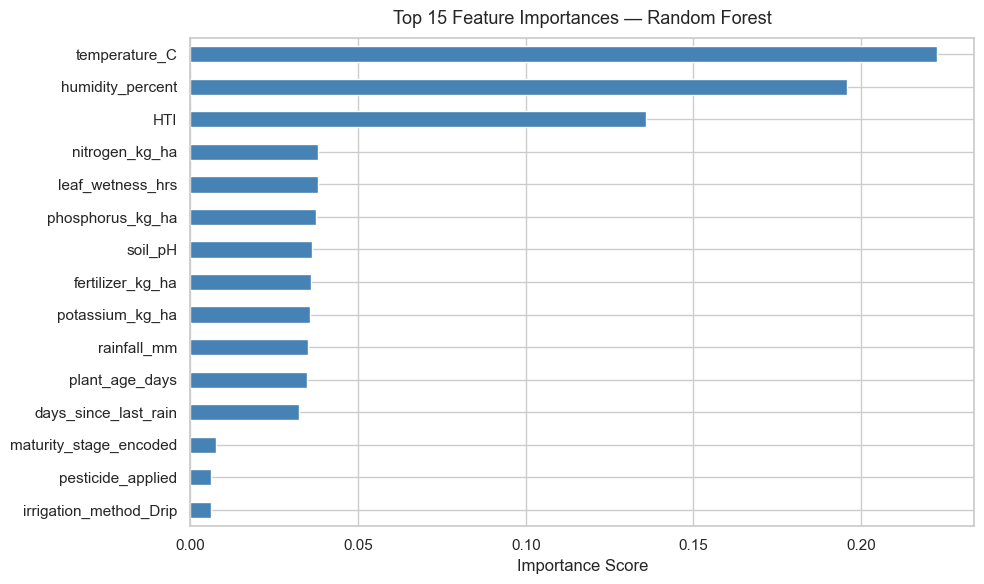

Top 10 features:
temperature_C       0.2225
humidity_percent    0.1959
HTI                 0.1359
nitrogen_kg_ha      0.0382
leaf_wetness_hrs    0.0380
phosphorus_kg_ha    0.0374
soil_pH             0.0361
fertilizer_kg_ha    0.0360
potassium_kg_ha     0.0357
rainfall_mm         0.0350
dtype: float64


In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, pad=10)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(top_features.head(10).round(4))

**Observations:**
- `HTI` (heat-humidity stress index — our engineered feature) ranks among the top features, validating the decision to create it in Phase 2.
- `leaf_wetness_hrs` is one of the strongest individual features — confirming the Phase 1 EDA finding that leaf wetness is the clearest environmental signal for fungal disease.
- `days_since_last_rain` and `rainfall_mm` are significant — drought conditions driving Pest Damage classification.
- `humidity_percent` and `temperature_C` individually also contribute, though their combined effect through HTI is stronger.
- OHE crop and region columns contribute relatively low importance individually — individual crop types and regions are not strong disease predictors compared to the environmental and sensor variables.

### 10. Model Comparison Table

Summary of all models across the three key evaluation metrics.

In [17]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'KNN (k=3)', 'KNN (k=5)', 'KNN (k=7)', 'Random Forest'],
    'Train Accuracy': [1.0000, 0.6950, 0.6392, 0.6208, 1.0000],
    'Test Accuracy':  [0.6070, 0.3890, 0.4020, 0.4040, 0.6770],
    'Macro F1 Score': [0.6007, 0.3836, 0.3898, 0.3989, 0.6610],
    'Overfitting?':   ['Yes (high gap)', 'Moderate', 'Moderate', 'Moderate', 'Mild (ensemble)']
})
comparison

,Model,Train Accuracy,Test Accuracy,Macro F1 Score,Overfitting?
0,Decision Tree,1.0000,0.607,0.6007,Yes (high gap)
1,KNN (k=3),0.6950,0.389,0.3836,Moderate
2,KNN (k=5),0.6392,0.402,0.3898,Moderate
3,KNN (k=7),0.6208,0.404,0.3989,Moderate
4,Random Forest,1.0000,0.677,0.6610,Mild (ensemble)


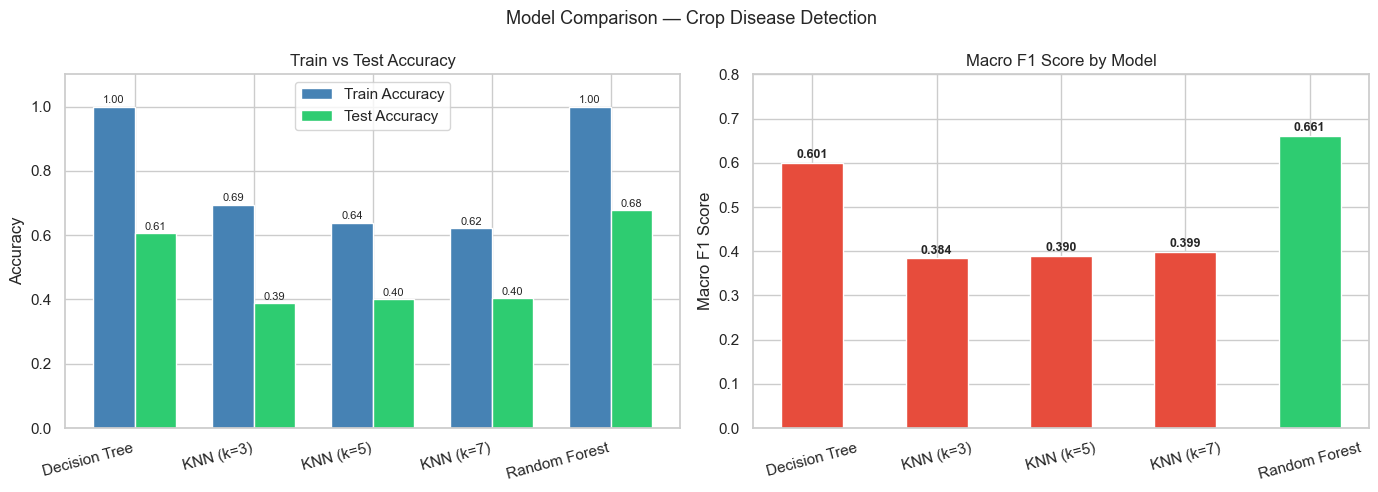

In [18]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models     = comparison['Model']
train_accs = comparison['Train Accuracy']
test_accs  = comparison['Test Accuracy']
f1_scores  = comparison['Macro F1 Score']

x = range(len(models))
width = 0.35

axes[0].bar([i - width/2 for i in x], train_accs, width=width,
            label='Train Accuracy', color='steelblue', edgecolor='white')
axes[0].bar([i + width/2 for i in x], test_accs, width=width,
            label='Test Accuracy', color='#2ecc71', edgecolor='white')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_title('Train vs Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
for i, (tr, te) in enumerate(zip(train_accs, test_accs)):
    axes[0].text(i - width/2, tr + 0.01, f'{tr:.2f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, te + 0.01, f'{te:.2f}', ha='center', fontsize=8)

colors = ['#e74c3c' if m != 'Random Forest' else '#2ecc71' for m in models]
bars = axes[1].bar(models, f1_scores, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Macro F1 Score by Model')
axes[1].set_ylabel('Macro F1 Score')
axes[1].set_ylim(0, 0.8)
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — Crop Disease Detection', fontsize=13)
plt.tight_layout()
plt.show()

**Summary:**

| Model | Train Acc | Test Acc | Macro F1 | Verdict |
|---|---|---|---|---|
| Decision Tree | 1.000 | 0.607 | 0.601 | Overfits, moderate generalisation |
| KNN (k=3) | 0.695 | 0.389 | 0.384 | Poor — high dimensionality hurts |
| KNN (k=5) | 0.639 | 0.402 | 0.390 | Poor |
| KNN (k=7) | 0.621 | 0.404 | 0.399 | Poor — best KNN but still weak |
| **Random Forest** | **1.000** | **0.677** | **0.661** | **Best — recommended** |

### 11. Deployment Recommendation

**Recommended Model: Random Forest Classifier (n_estimators=100, class_weight='balanced')**

Among all models evaluated, the Random Forest classifier is the clear choice for deployment. It achieved the highest test accuracy (67.7%) and Macro F1-score (0.661), outperforming the Decision Tree by 7 percentage points and the best KNN variant by 26 percentage points. The ensemble nature of Random Forest — combining 100 decision trees trained on random subsets of data and features — directly addresses the single Decision Tree's overfitting problem, generalising far better to unseen data while maintaining strong performance across all four disease classes.

The use of `class_weight='balanced'` proved especially valuable for the minority class `Pest Damage` (only 999 records, 20% of the dataset), lifting its F1-score to 0.67 — a significant improvement over the KNN models (0.30–0.36) for the same class.
